<a href="https://colab.research.google.com/github/banteamlak1888/Programming-and-Algorithms-Course/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
path='/content/drive/MyDrive/new_housing.csv'
home_data=pd.read_csv(path)

In [ ]:
# Load the dataset
home_data = pd.read_csv(path, usecols=['longitude', 'latitude', 'median_house_value'])

In [ ]:
# Extract features
X = home_data[['latitude', 'longitude']].to_numpy()
y = home_data[['median_house_value']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)


In [ ]:
 #provides a statistical summary of the dataset.
print(home_data.describe())

          longitude      latitude  median_house_value
count  20640.000000  20640.000000        20640.000000
mean    -119.569704     35.631861       206855.816909
std        2.003532      2.135952       115395.615874
min     -124.350000     32.540000        14999.000000
25%     -121.800000     33.930000       119600.000000
50%     -118.490000     34.260000       179700.000000
75%     -118.010000     37.710000       264725.000000
max     -114.310000     41.950000       500001.000000


In [ ]:
print(home_data)

       longitude  latitude  median_house_value
0        -122.23     37.88            452600.0
1        -122.22     37.86            358500.0
2        -122.24     37.85            352100.0
3        -122.25     37.85            341300.0
4        -122.25     37.85            342200.0
...          ...       ...                 ...
20635    -121.09     39.48             78100.0
20636    -121.21     39.49             77100.0
20637    -121.22     39.43             92300.0
20638    -121.32     39.43             84700.0
20639    -121.24     39.37             89400.0

[20640 rows x 3 columns]


In [ ]:
home_data.head(8), home_data.tail(8)

(   longitude  latitude  median_house_value
 0    -122.23     37.88            452600.0
 1    -122.22     37.86            358500.0
 2    -122.24     37.85            352100.0
 3    -122.25     37.85            341300.0
 4    -122.25     37.85            342200.0
 5    -122.25     37.85            269700.0
 6    -122.25     37.84            299200.0
 7    -122.25     37.84            241400.0,
        longitude  latitude  median_house_value
 20632    -121.45     39.26            115600.0
 20633    -121.53     39.19             98300.0
 20634    -121.56     39.27            116800.0
 20635    -121.09     39.48             78100.0
 20636    -121.21     39.49             77100.0
 20637    -121.22     39.43             92300.0
 20638    -121.32     39.43             84700.0
 20639    -121.24     39.37             89400.0)

In [ ]:
# Normalize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_norm = normalize(X_train)
X_test_norm = normalize(X_test)


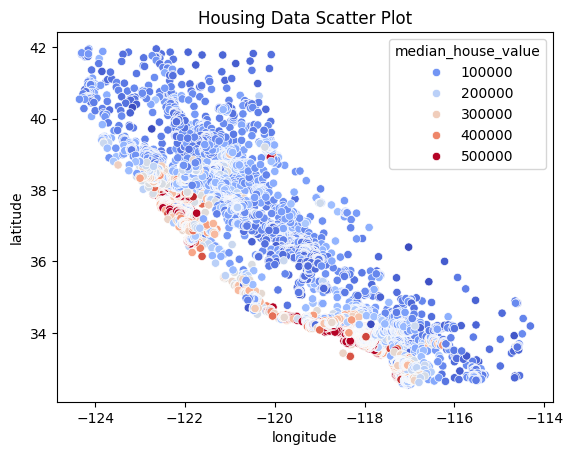

In [ ]:
# Visualize the data
sns.scatterplot(data=home_data, x='longitude', y='latitude', hue='median_house_value', palette='coolwarm')
plt.title('Housing Data Scatter Plot')
plt.show()

In [ ]:
# Explanation of K-Means clustering steps
def kmeans_explanation(X, k):
    # Step 1: Choose the number of clusters k
    # Step 2: Select k random points from the data as initial centroids
    centroids = X.sample(n=k, random_state=0).values

    for iteration in range(10):
        clusters = {}
        for point in X.values:
            distances = [((point - centroid) ** 2).sum() for centroid in centroids]
            closest_centroid = distances.index(min(distances))
            if closest_centroid not in clusters:
                clusters[closest_centroid] = []
            clusters[closest_centroid].append(point)

 # Step 4: Move each centroid to minimize the distance to its points
        new_centroids = []
        for cluster_id, points in clusters.items():
            new_centroid = pd.DataFrame(points).mean().values
            new_centroids.append(new_centroid)
        centroids = new_centroids

    return centroids, clusters

In [ ]:
# Determine  number of clusters using the elbow method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(X_train_norm)
    inertia.append(kmeans.inertia_)

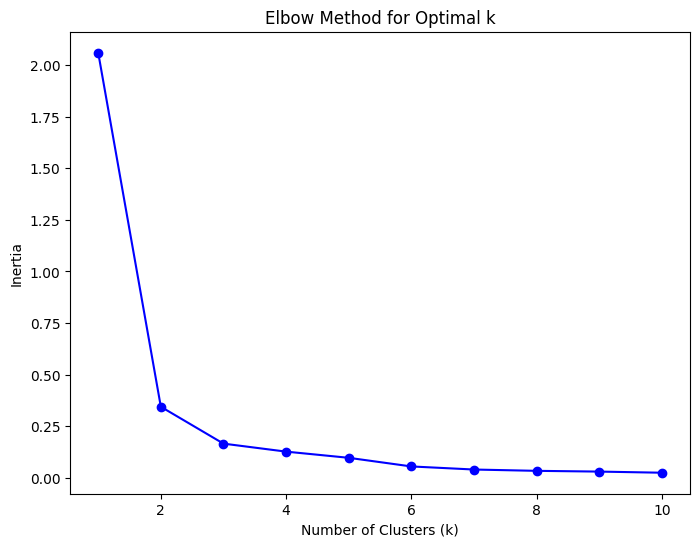

In [ ]:
# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
# You can adjust this based on the elbow plot
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=0, n_init='auto')
kmeans.fit(X_train_norm)

KMeans(n_clusters=3, n_init='auto', random_state=0)

In [ ]:
# You can adjust this based on the elbow plot
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=0, n_init='auto')
kmeans.fit(X_train_norm)
# Visualize the clusters and centroids
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=final_labels, palette='viridis', legend='full', s=200)
#sns.scatterplot(x=X_train['longitude'], y=X_train['latitude'], hue=kmeans.labels_, palette='coolwarm', legend='full', s=200)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 1], centroids[:, 0], color='red', marker='x', s=100, label='Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'K-Means Clustering (k={optimal_k})')
plt.legend()
plt.show()

NameError: name 'final_labels' is not defined

<Figure size 1000x700 with 0 Axes>